# Análise da Série `UnempRate` — Lista 4

Este notebook resolve as **questões 2, 3 e 4** da lista, utilizando a série `UnempRate` (taxa mensal de desemprego).  
O roteiro segue a ordem:

1. Carregamento e visualização da série
2. Teste de raiz unitária (ADF e KPSS)
3. Detecção de *outliers*
4. Ajuste de modelo ARIMA e previsões (**Questão 2**)
5. Alisamento exponencial e previsões (**Questão 3**)
6. Comparação dos dois modelos (**Questão 4**)

---
## 0. Pacotes necessários

Instalamos e carregamos todos os pacotes de uma vez.  
- `tseries` — testes ADF e KPSS  
- `forecast` — auto.arima, ets, previsões  
- `tsoutliers` — detecção automática de outliers  
- `ggplot2` / `ggfortify` — gráficos elegantes de séries temporais  
- `readxl` — leitura do arquivo Excel

In [4]:
# Instala pacotes ausentes automaticamente
pkgs <- c("readxl", "tseries", "forecast", "tsoutliers", "ggplot2", "ggfortify")
suppressPackageStartupMessages({
  library(readxl)
  library(tseries)
  library(forecast)
  library(tsoutliers)
  library(ggplot2)
  library(ggfortify)
})

cat("Pacotes carregados com sucesso!\n")

Pacotes carregados com sucesso!


---
## 1. Carregamento e Visualização da Série

Lemos o arquivo Excel e convertemos para objeto `ts`.  
Como a série é **mensal**, usamos `frequency = 12`.  
Ajuste o argumento `start` conforme o ano de início real dos seus dados.

In [5]:
# --- Leitura dos dados ---
dados <- read_excel("lista4.xlsx")

# Inspeciona as primeiras linhas para confirmar a estrutura
head(dados)

tempo,X
<dbl>,<dbl>
1,4.0
2,4.7
3,4.5
4,4.0
5,3.4
6,3.9


In [6]:
# --- Criação do objeto ts ---
# 'frequency = 12' indica série mensal.
# Ajuste 'start = c(ANO, MES_INICIAL)' conforme seus dados.
serie <- ts(dados$X, frequency = 12)

# Resumo estatístico básico
cat("=== Resumo da série ===\n")
print(summary(serie))
cat("\nNúmero de observações:", length(serie), "\n")

=== Resumo da série ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.400   4.700   5.600   5.812   6.900  11.400 

Número de observações: 827 


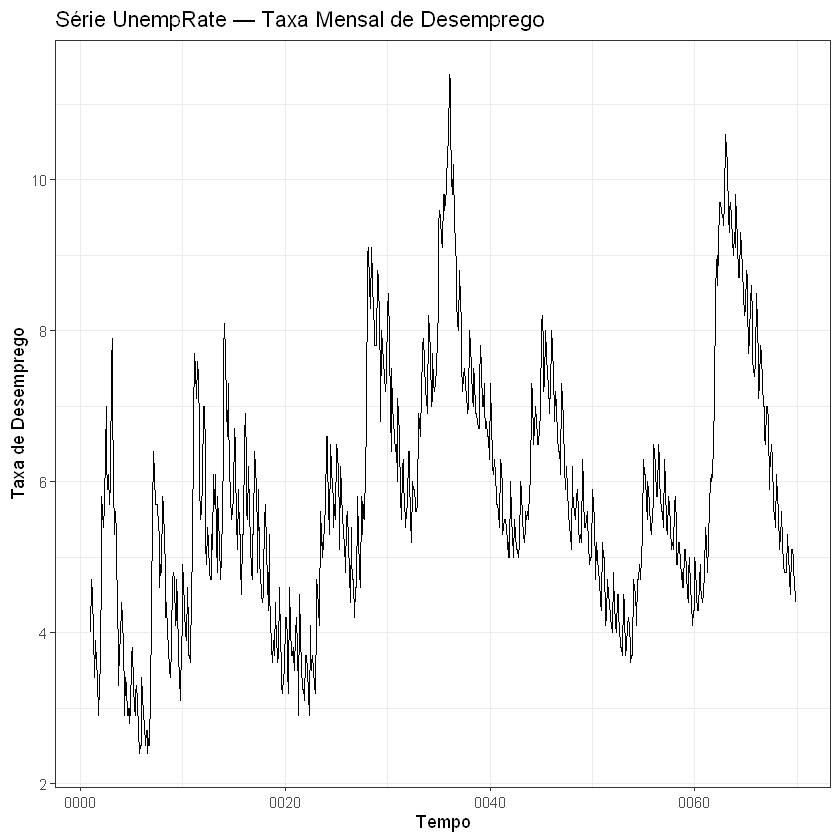

In [7]:
# --- Gráfico da série original ---
autoplot(serie) +
  ggtitle("Série UnempRate — Taxa Mensal de Desemprego") +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  theme_bw()

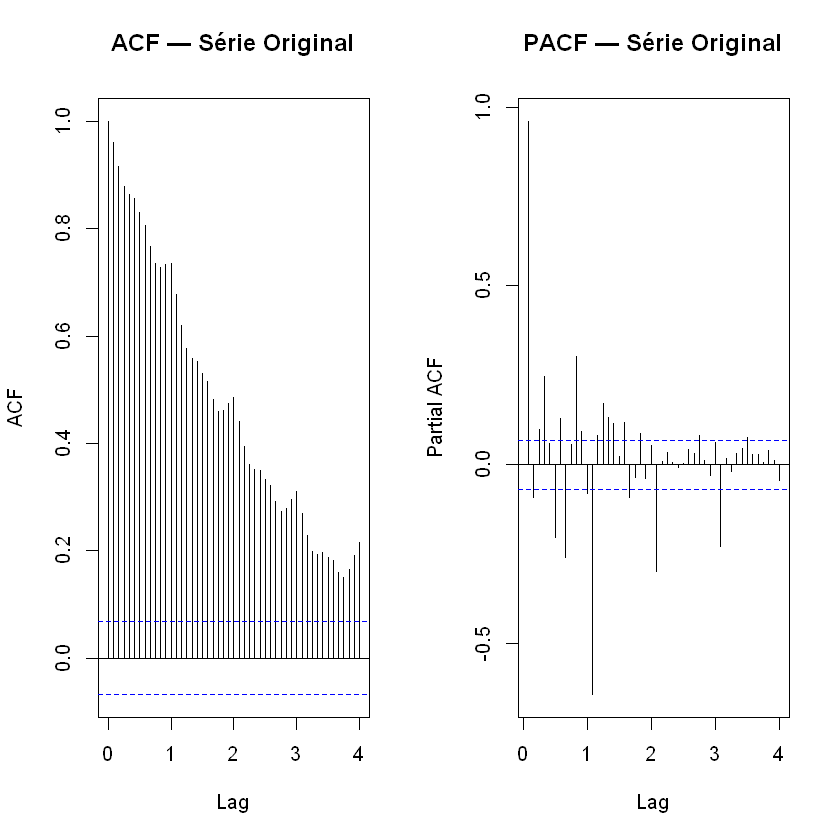

In [8]:
# --- ACF e PACF da série original ---
# A ACF decai lentamente? → indício de não-estacionariedade / raiz unitária
par(mfrow = c(1, 2))
acf(serie,  lag.max = 48, main = "ACF — Série Original")
pacf(serie, lag.max = 48, main = "PACF — Série Original")
par(mfrow = c(1, 1))

---
## 2. Questão 2 — Teste de Raiz Unitária

Utilizamos dois testes complementares:

| Teste | H₀ | H₁ |
|-------|----|----|  
| **ADF** | Existe raiz unitária (não-estacionária) | Estacionária |
| **KPSS** | Estacionária | Existe raiz unitária |

Se ADF **não rejeita** H₀ **e** KPSS **rejeita** H₀ → forte evidência de raiz unitária → precisamos diferenciar.

In [9]:
# --- Teste ADF (Augmented Dickey-Fuller) ---
# type = 'ct': inclui constante e tendência (mais geral)
adf_orig <- adf.test(serie, alternative = "stationary")
cat("=== Teste ADF — Série Original ===\n")
print(adf_orig)

cat("\nInterpretação: ")
if (adf_orig$p.value > 0.05) {
  cat("p-valor =", round(adf_orig$p.value, 4),
      "→ NÃO rejeitamos H0 (evidência de raiz unitária).\n")
} else {
  cat("p-valor =", round(adf_orig$p.value, 4),
      "→ Rejeitamos H0 (série provavelmente estacionária).\n")
}

=== Teste ADF — Série Original ===

	Augmented Dickey-Fuller Test

data:  serie
Dickey-Fuller = -2.5923, Lag order = 9, p-value = 0.3276
alternative hypothesis: stationary


Interpretação: p-valor = 0.3276 → NÃO rejeitamos H0 (evidência de raiz unitária).


In [10]:
# --- Teste KPSS ---
# null = 'Level': H0 é estacionariedade em nível
kpss_orig <- kpss.test(serie, null = "Level")
cat("=== Teste KPSS — Série Original ===\n")
print(kpss_orig)

cat("\nInterpretação: ")
if (kpss_orig$p.value < 0.05) {
  cat("p-valor =", round(kpss_orig$p.value, 4),
      "→ Rejeitamos H0 (evidência de raiz unitária).\n")
} else {
  cat("p-valor =", round(kpss_orig$p.value, 4),
      "→ NÃO rejeitamos H0 (série consistente com estacionariedade).\n")
}

Warning message in kpss.test(serie, null = "Level"):
"p-value smaller than printed p-value"


=== Teste KPSS — Série Original ===

	KPSS Test for Level Stationarity

data:  serie
KPSS Level = 1.8274, Truncation lag parameter = 6, p-value = 0.01


Interpretação: p-valor = 0.01 → Rejeitamos H0 (evidência de raiz unitária).


Número de diferenciações sugerido por ndiffs(): 1 


Warning message in adf.test(serie_diff, alternative = "stationary"):
"p-value smaller than printed p-value"
Warning message in kpss.test(serie_diff, null = "Level"):
"p-value greater than printed p-value"



=== Testes na série diferenciada (d = 1 ) ===
ADF  p-valor: 0.01 
KPSS p-valor: 0.1 


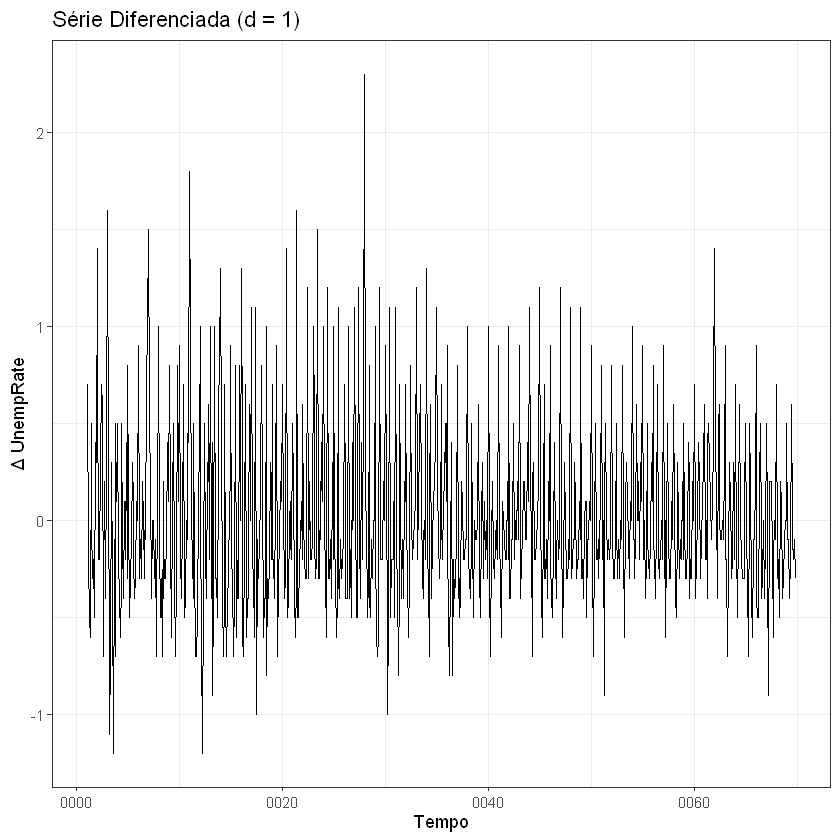

In [11]:
# --- Diferenciação (se necessária) ---
# ndiffs() do pacote forecast sugere o número de diferenças necessárias
nd <- ndiffs(serie)
cat("Número de diferenciações sugerido por ndiffs():", nd, "\n")

if (nd > 0) {
  serie_diff <- diff(serie, differences = nd)
  
  # Verifica estacionariedade após diferenciar
  adf_diff  <- adf.test(serie_diff, alternative = "stationary")
  kpss_diff <- kpss.test(serie_diff, null = "Level")
  
  cat("\n=== Testes na série diferenciada (d =", nd, ") ===\n")
  cat("ADF  p-valor:", round(adf_diff$p.value,  4), "\n")
  cat("KPSS p-valor:", round(kpss_diff$p.value, 4), "\n")
  
  # Gráfico da série diferenciada
  autoplot(serie_diff) +
    ggtitle(paste0("Série Diferenciada (d = ", nd, ")")) +
    xlab("Tempo") + ylab("Δ UnempRate") +
    theme_bw()
} else {
  cat("Série já é estacionária em nível — nenhuma diferenciação necessária.\n")
}

---
## 2 (cont.) — Detecção de *Outliers*

Usamos a função `tso()` do pacote `tsoutliers`, que detecta automaticamente:

- **AO** (*Additive Outlier*): pico/vale isolado em um único instante  
- **IO** (*Innovational Outlier*): choque que persiste nos períodos seguintes  
- **LS** (*Level Shift*): mudança permanente no nível da série  
- **TC** (*Temporary Change*): mudança que decai gradualmente

In [12]:
# --- Detecção automática de outliers com tso() ---
# Ajustamos primeiro um ARIMA automático para identificar a estrutura,
# depois o tso() itera buscando outliers.
cat("Executando detecção de outliers... (pode demorar alguns segundos)\n")

outliers_result <- tso(
  serie,
  types  = c("AO", "IO", "LS", "TC"),  # tipos a testar
  maxit  = 10,                           # máximo de iterações
  delta  = 0.7                           # taxa de decaimento para TC
)

cat("\n=== Resultado da detecção de outliers ===\n")
print(outliers_result)

Executando detecção de outliers... (pode demorar alguns segundos)

=== Resultado da detecção de outliers ===
Series: serie 
Regression with ARIMA(4,0,0)(2,1,1)[12] errors 

Coefficients:
         ar1     ar2      ar3      ar4    sar1    sar2     sma1   IO325
      1.0861  0.0924  -0.0873  -0.1154  0.0408  0.0456  -0.7929  1.2694
s.e.  0.0354  0.0525   0.0519   0.0350  0.0615  0.0528   0.0481  0.2312

sigma^2 = 0.05328:  log likelihood = 35.92
AIC=-53.85   AICc=-53.62   BIC=-11.52

Outliers:
  type ind  time coefhat tstat
1   IO 325 28:01   1.269  5.49


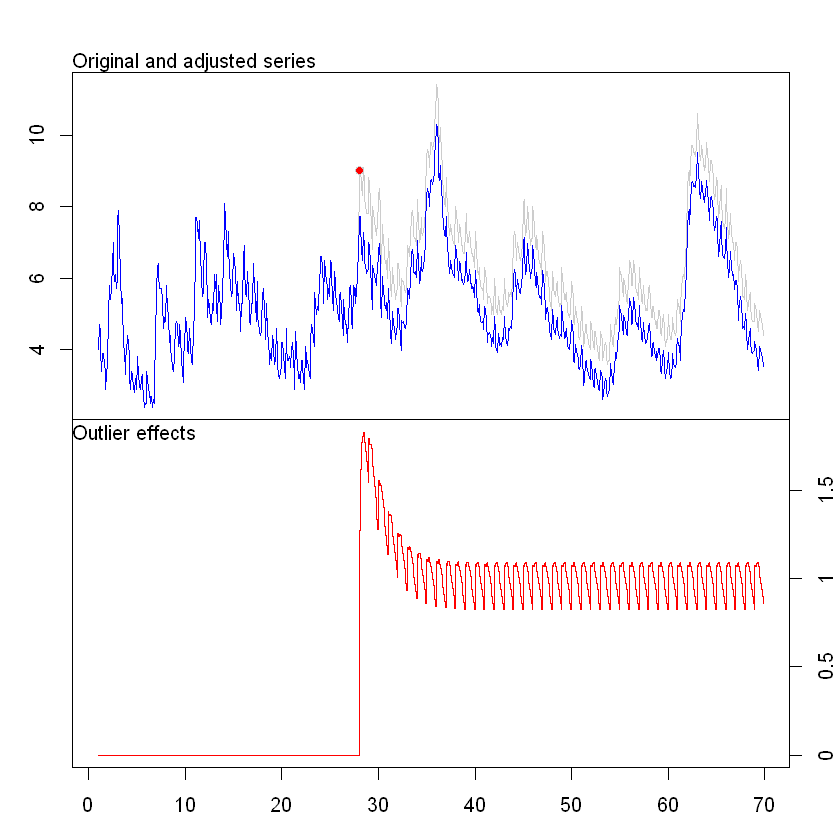

In [13]:
# --- Visualização dos outliers na série ---
plot(outliers_result)

In [14]:
# --- Tabela dos outliers detectados ---
if (!is.null(outliers_result$outliers) && nrow(outliers_result$outliers) > 0) {
  cat("Outliers detectados:\n")
  print(outliers_result$outliers)
} else {
  cat("Nenhum outlier significativo detectado na série.\n")
}

Outliers detectados:
  type ind  time  coefhat    tstat
1   IO 325 28:01 1.269428 5.490219


---
## 2 (cont.) — Ajuste do Modelo ARIMA e Previsões

Usamos `auto.arima()` para selecionar automaticamente a ordem $(p, d, q)(P, D, Q)_s$ por critério de informação (AIC/BIC).  
Em seguida, verificamos os resíduos e geramos previsões 12 passos à frente.

In [15]:
# --- Ajuste automático do ARIMA ---
# stepwise = FALSE e approximation = FALSE: busca mais completa (mais lenta)
cat("Ajustando ARIMA... (pode demorar)\n")
modelo_arima <- auto.arima(
  serie,
  stepwise     = FALSE,
  approximation = FALSE,
  trace        = FALSE
)

cat("\n=== Modelo ARIMA selecionado ===\n")
print(summary(modelo_arima))

Ajustando ARIMA... (pode demorar)

=== Modelo ARIMA selecionado ===
Series: serie 
ARIMA(3,0,1)(0,1,1)[12] 

Coefficients:
         ar1      ar2      ar3      ma1     sma1
      1.6979  -0.5957  -0.1132  -0.6197  -0.7538
s.e.  0.0908   0.1312   0.0469   0.0872   0.0268

sigma^2 = 0.05448:  log likelihood = 25.3
AIC=-38.59   AICc=-38.49   BIC=-10.37

Training set error measures:
                      ME     RMSE       MAE          MPE     MAPE      MASE
Training set 0.003227908 0.231003 0.1753853 -0.003109258 3.289598 0.1996076
                    ACF1
Training set 0.003210108



	Ljung-Box test

data:  Residuals from ARIMA(3,0,1)(0,1,1)[12]
Q* = 21.097, df = 19, p-value = 0.3315

Model df: 5.   Total lags used: 24



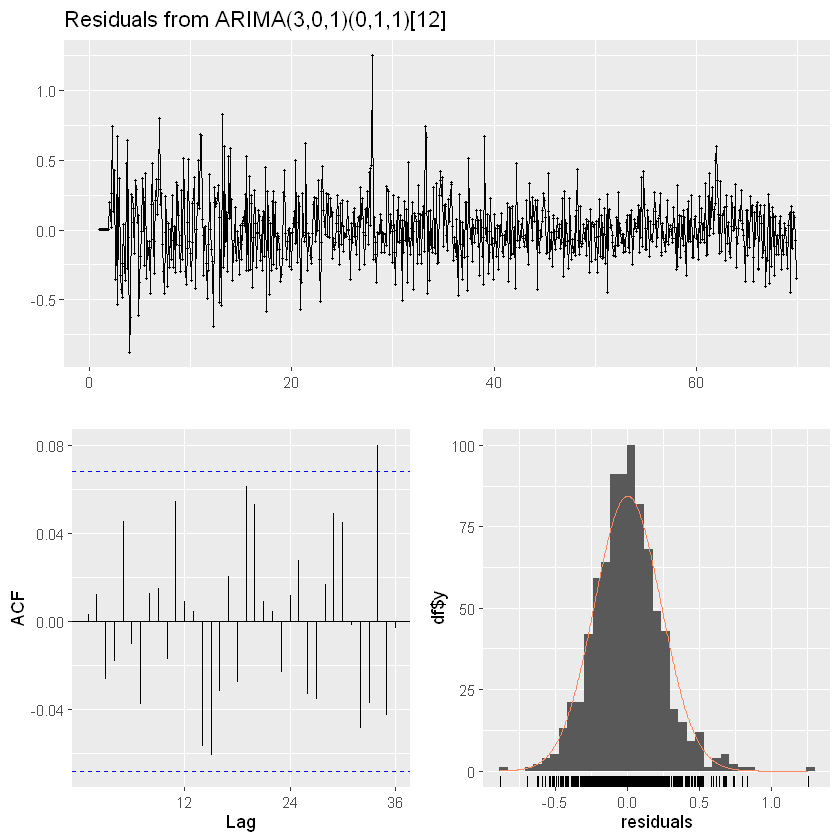

In [16]:
# --- Diagnóstico dos resíduos ---
# Queremos resíduos sem autocorrelação (ruído branco)
# Teste de Ljung-Box: H0 = resíduos são ruído branco
checkresiduals(modelo_arima)

=== Previsões ARIMA ===
       Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Dec 69       4.481716 4.182584 4.780849 4.024232 4.939200
Jan 70       5.176881 4.737010 5.616753 4.504156 5.849606
Feb 70       5.071831 4.497445 5.646218 4.193383 5.950279
Mar 70       4.920573 4.219967 5.621179 3.849089 5.992057
Apr 70       4.445259 3.626045 5.264472 3.192380 5.698137
May 70       4.583398 3.653461 5.513334 3.161183 6.005613
Jun 70       5.079853 4.047253 6.112452 3.500628 6.659078
Jul 70       5.224775 4.097624 6.351925 3.500947 6.948602
Aug 70       5.057826 3.844151 6.271500 3.201671 6.913980
Sep 70       4.816624 3.524250 6.108999 2.840108 6.793141
Oct 70       4.779136 3.415588 6.142685 2.693769 6.864504
Nov 70       4.744449 3.316886 6.172012 2.561179 6.927718


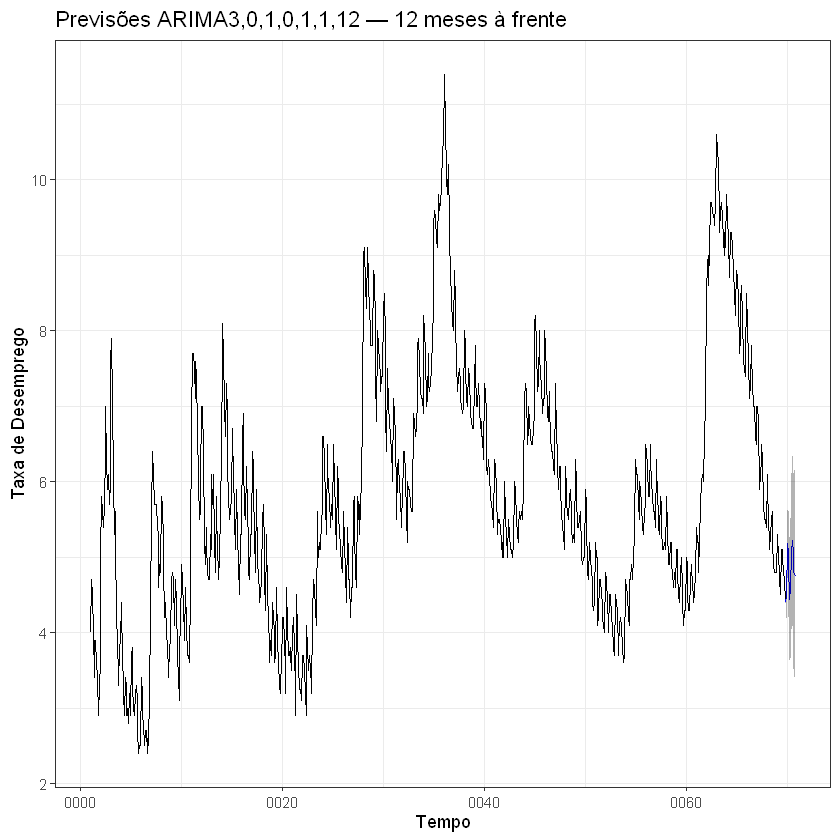

In [17]:
# --- Previsões ARIMA — 12 passos à frente ---
h_previsao <- 12  # horizonte de previsão (meses)

prev_arima <- forecast(modelo_arima, h = h_previsao, level = c(80, 95))

cat("=== Previsões ARIMA ===\n")
print(prev_arima)

# Gráfico das previsões
autoplot(prev_arima) +
  ggtitle(paste0("Previsões ARIMA", 
                  paste0(arimaorder(modelo_arima), collapse=","), 
                  " — 12 meses à frente")) +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  theme_bw()

---
## 3. Questão 3 — Alisamento Exponencial (ETS)

O framework **ETS** (Error, Trend, Seasonality) generaliza os métodos clássicos de alisamento:

| Componente | Opções |
|------------|--------|
| **E**rro | Aditivo (A) / Multiplicativo (M) |
| **T**endência | Nenhuma (N) / Aditiva (A) / Amortecida (Ad) |
| **S**azonalidade | Nenhuma (N) / Aditiva (A) / Multiplicativa (M) |

A função `ets()` seleciona automaticamente o melhor modelo por AIC.

In [18]:
# --- Ajuste do modelo ETS ---
modelo_ets <- ets(serie)

cat("=== Modelo ETS selecionado ===\n")
print(summary(modelo_ets))

cat("\nModelo escolhido:", modelo_ets$method, "\n")
cat("Parâmetros de suavização:\n")
cat("  alpha (nível)    =", round(modelo_ets$par["alpha"], 4), "\n")
if ("beta"  %in% names(modelo_ets$par))
  cat("  beta (tendência) =", round(modelo_ets$par["beta"],  4), "\n")
if ("gamma" %in% names(modelo_ets$par))
  cat("  gamma (sazonal)  =", round(modelo_ets$par["gamma"], 4), "\n")
if ("phi"   %in% names(modelo_ets$par))
  cat("  phi (amortec.)   =", round(modelo_ets$par["phi"],   4), "\n")

=== Modelo ETS selecionado ===
ETS(A,Ad,A) 

Call:
ets(y = serie)

  Smoothing parameters:
    alpha = 0.9187 
    beta  = 0.1294 
    gamma = 0.0796 
    phi   = 0.801 

  Initial states:
    l = 2.7779 
    b = -0.5788 
    s = -0.3924 -0.5681 -0.7373 -0.4502 -0.1988 0.3703
           0.4193 -0.1723 0.009 0.4228 0.7208 0.577

  sigma:  0.2527

     AIC     AICc      BIC 
3299.495 3300.341 3384.415 

Training set error measures:
                      ME      RMSE       MAE        MPE     MAPE     MASE
Training set 0.003579053 0.2501211 0.1910467 0.09533694 3.563321 0.217432
                  ACF1
Training set 0.1070446

Modelo escolhido: ETS(A,Ad,A) 
Parâmetros de suavização:
  alpha (nível)    = 0.9187 
  beta (tendência) = 0.1294 
  gamma (sazonal)  = 0.0796 
  phi (amortec.)   = 0.801 



	Ljung-Box test

data:  Residuals from ETS(A,Ad,A)
Q* = 104.21, df = 24, p-value = 5.692e-12

Model df: 0.   Total lags used: 24



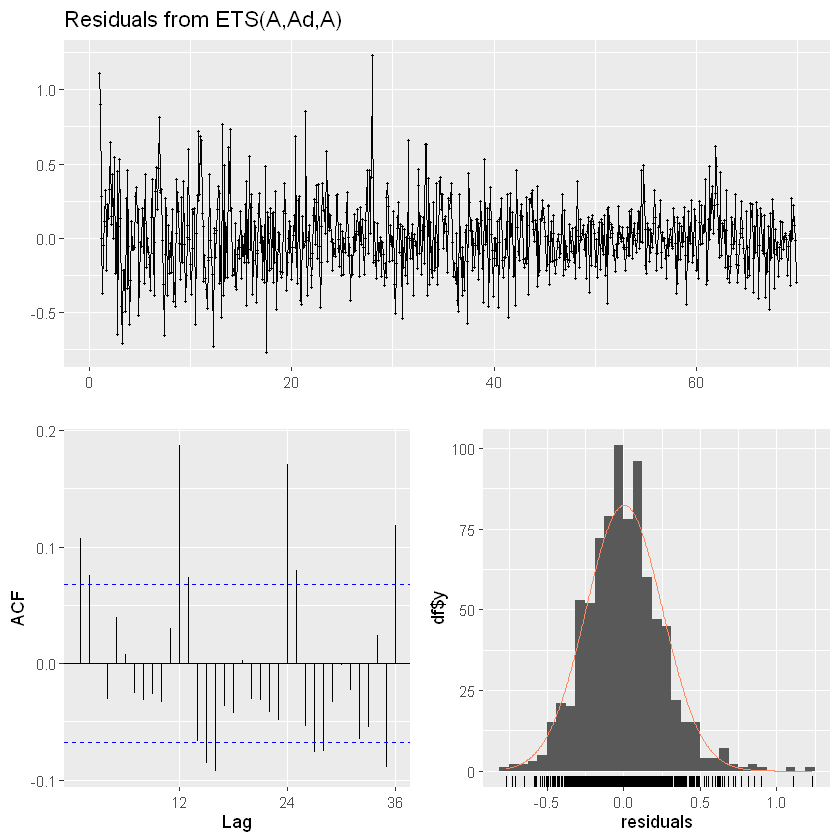

In [19]:
# --- Diagnóstico dos resíduos ETS ---
checkresiduals(modelo_ets)

=== Previsões ETS ===
       Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Dec 69       4.421548 4.097659 4.745438 3.926202 4.916894
Jan 70       5.141400 4.678223 5.604577 4.433032 5.849768
Feb 70       5.108099 4.522707 5.693490 4.212819 6.003378
Mar 70       5.010255 4.312609 5.707902 3.943297 6.077214
Apr 70       4.584131 3.781557 5.386705 3.356701 5.811562
May 70       4.685716 3.784224 5.587209 3.307003 6.064430
Jun 70       5.075365 4.080146 6.070583 3.553310 6.597419
Jul 70       5.081328 3.996994 6.165662 3.422983 6.739674
Aug 70       4.777734 3.608435 5.947034 2.989445 6.566024
Sep 70       4.477786 3.227285 5.728286 2.565310 6.390261
Oct 70       4.366845 3.038576 5.695114 2.335433 6.398257
Nov 70       4.321959 2.919060 5.724857 2.176411 6.467507


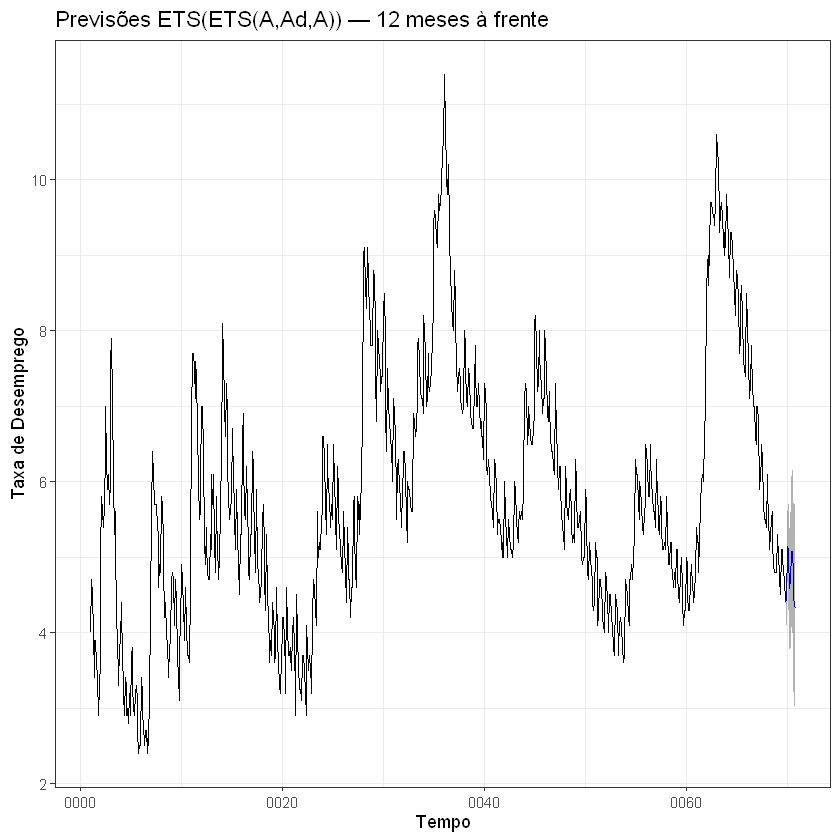

In [20]:
# --- Previsões ETS — 12 passos à frente ---
prev_ets <- forecast(modelo_ets, h = h_previsao, level = c(80, 95))

cat("=== Previsões ETS ===\n")
print(prev_ets)

# Gráfico das previsões
autoplot(prev_ets) +
  ggtitle(paste0("Previsões ETS(", modelo_ets$method, ") — 12 meses à frente")) +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  theme_bw()


Forecast method: Holt-Winters' additive method

Model Information:
Holt-Winters' additive method 

Call:
hw(y = serie, h = 12, seasonal = "additive")

  Smoothing parameters:
    alpha = 0.8539 
    beta  = 0.0014 
    gamma = 0.1458 

  Initial states:
    l = 2.5948 
    b = -0.0096 
    s = -0.6752 -0.3594 -0.6546 -0.2958 -0.3413 0.1712
           0.2713 -0.3058 0.2478 0.483 0.8937 0.5652

  sigma:  0.2655

     AIC     AICc      BIC 
3380.334 3381.090 3460.536 

Error measures:
                      ME      RMSE       MAE        MPE    MAPE     MASE
Training set 0.005698987 0.2629672 0.1983887 0.06352794 3.66417 0.225788
                  ACF1
Training set 0.3101631

Forecasts:
       Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
Dec 69       4.547868 4.207554 4.888182 4.027402 5.068334
Jan 70       5.269040 4.821238 5.716842 4.584186 5.953894
Feb 70       5.159907 4.625571 5.694243 4.342711 5.977103
Mar 70       4.968898 4.359982 5.577814 4.037642 5.900155
Apr 70       4.458

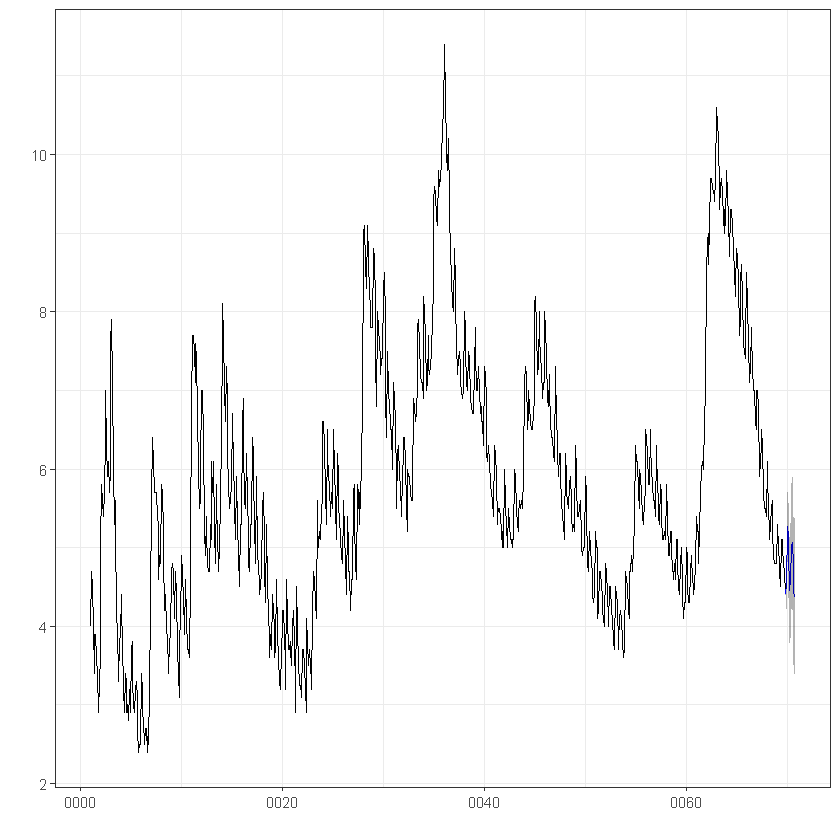

In [33]:
# Holt-Winters aditivo (sazonalidade de amplitude constante)
modelo_hw <- hw(serie, seasonal = "additive", h = 12)

# — ou multiplicativo (sazonalidade proporcional ao nível) —
# modelo_hw <- hw(serie, seasonal = "multiplicative", h = 12)

summary(modelo_hw)
autoplot(modelo_hw) + theme_bw()

---
## 4. Questão 4 — Comparação dos Modelos ARIMA vs ETS

Comparamos os dois modelos sob três perspectivas:

1. **Métricas de ajuste in-sample** (AIC, BIC, RMSE, MAE)  
2. **Validação cruzada (rolling forecast origin)** — erro de previsão fora da amostra  
3. **Gráfico comparativo** das previsões

In [23]:
# --- 4.1 Métricas de ajuste in-sample ---
acc_arima <- accuracy(modelo_arima)
acc_ets   <- accuracy(modelo_ets)

metricas <- data.frame(
  Modelo = c("ARIMA", "ETS"),
  AIC    = c(AIC(modelo_arima), AIC(modelo_ets)),
  BIC    = c(BIC(modelo_arima), BIC(modelo_ets)),
  RMSE   = c(acc_arima[,"RMSE"], acc_ets[,"RMSE"]),
  MAE    = c(acc_arima[,"MAE"],  acc_ets[,"MAE"]),
  MAPE   = c(acc_arima[,"MAPE"], acc_ets[,"MAPE"])
)

cat("=== Comparação das métricas in-sample ===\n")
print(round(metricas[, -1], 4))

=== Comparação das métricas in-sample ===
        AIC       BIC   RMSE    MAE   MAPE
1  -38.5902  -10.3711 0.2310 0.1754 3.2896
2 3299.4948 3384.4153 0.2501 0.1910 3.5633


In [29]:
# --- 4.2 Comparação por hold-out (treino/teste) ---
# Reservamos os últimos 12 meses como conjunto de teste
n_teste <- 12

serie_treino <- head(serie, length(serie) - n_teste)
serie_teste  <- tail(serie, n_teste)

# Ajusta cada modelo apenas no conjunto de treino
arima_treino <- auto.arima(serie_treino, stepwise = TRUE, approximation = TRUE)
ets_treino   <- ets(serie_treino)

# Previsões para o período de teste
prev_arima_ho <- forecast(arima_treino, h = n_teste)
prev_ets_ho   <- forecast(ets_treino,   h = n_teste)

# Erros ponto a ponto
erro_arima <- as.numeric(serie_teste) - as.numeric(prev_arima_ho$mean)
erro_ets   <- as.numeric(serie_teste) - as.numeric(prev_ets_ho$mean)

# Métricas
rmse_ho <- data.frame(
  Modelo = c("ARIMA", "ETS"),
  RMSE   = c(sqrt(mean(erro_arima^2)), sqrt(mean(erro_ets^2))),
  MAE    = c(mean(abs(erro_arima)),    mean(abs(erro_ets))),
  MAPE   = c(mean(abs(erro_arima / as.numeric(serie_teste))) * 100,
             mean(abs(erro_ets   / as.numeric(serie_teste))) * 100)
)

cat("=== Comparação hold-out (últimos", n_teste, "meses) ===\n")
print(round(rmse_ho[-1], 4))

=== Comparação hold-out (últimos 12 meses) ===
    RMSE    MAE   MAPE
1 0.5278 0.4809 9.9655
2 0.2205 0.1814 3.7284


In [32]:
print(rmse_ho)


  Modelo      RMSE       MAE     MAPE
1  ARIMA 0.5277632 0.4808846 9.965532
2    ETS 0.2204504 0.1814263 3.728358


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


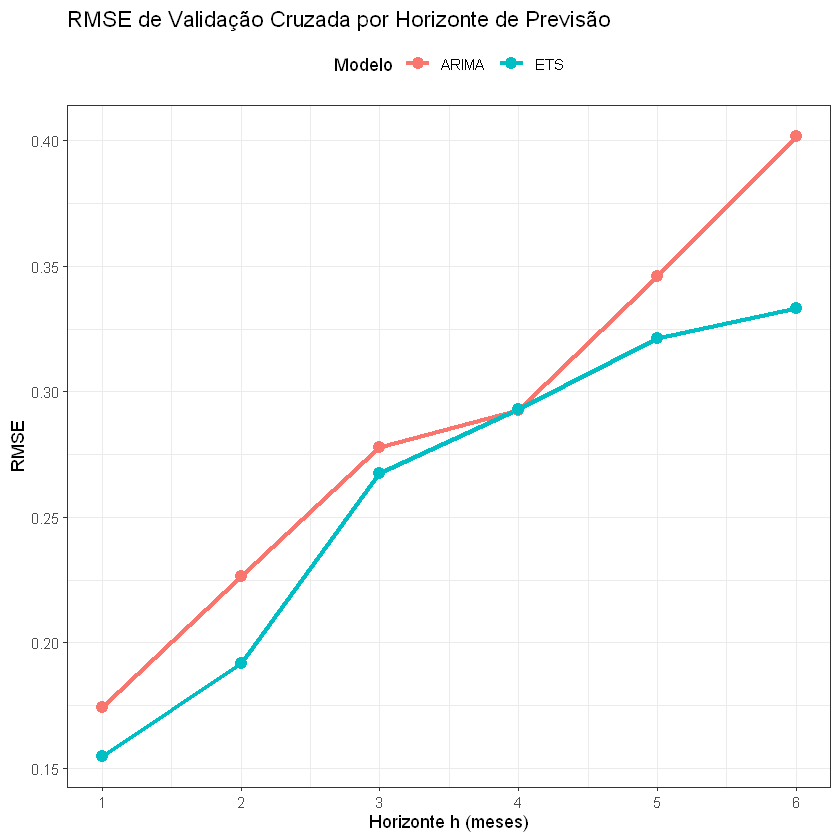

In [25]:
# --- Gráfico do RMSE por horizonte ---
rmse_long <- reshape2::melt(rmse_cv, id.vars = "h",
                            variable.name = "Modelo", value.name = "RMSE")

ggplot(rmse_long, aes(x = h, y = RMSE, colour = Modelo, group = Modelo)) +
  geom_line(size = 1.2) +
  geom_point(size = 3) +
  scale_x_continuous(breaks = 1:6) +
  ggtitle("RMSE de Validação Cruzada por Horizonte de Previsão") +
  xlab("Horizonte h (meses)") + ylab("RMSE") +
  theme_bw() +
  theme(legend.position = "top")

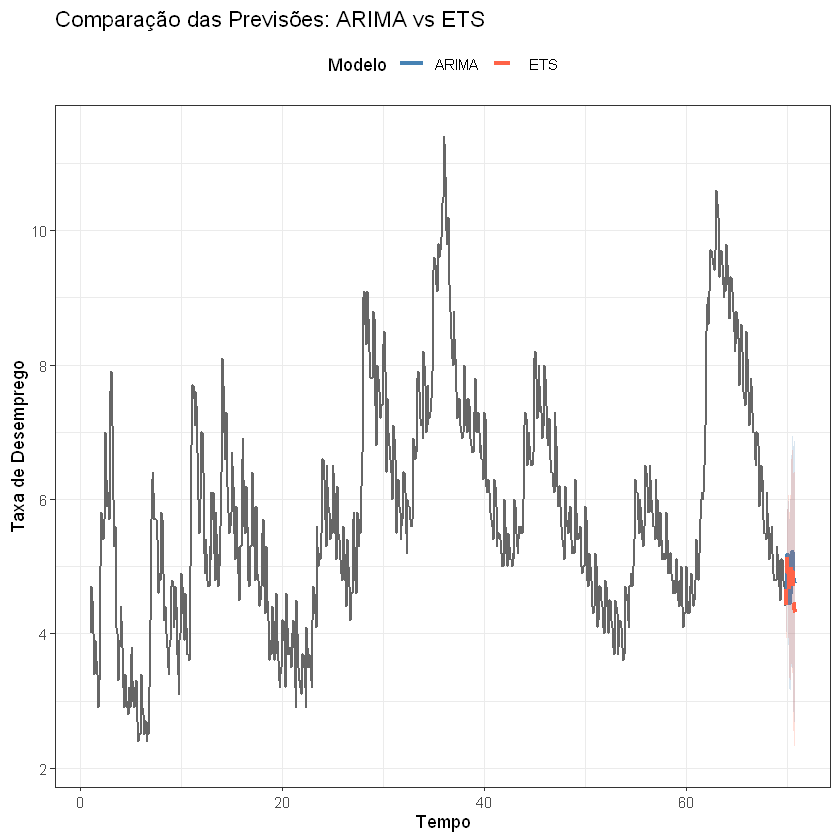

In [26]:
# --- 4.3 Gráfico comparativo das previsões ---
# Montamos um data frame com as previsões dos dois modelos

tempo_prev <- seq(end(serie)[1] + end(serie)[2]/12,
                  by = 1/12, length.out = h_previsao)

df_prev <- data.frame(
  tempo      = tempo_prev,
  ARIMA_mean = as.numeric(prev_arima$mean),
  ARIMA_lo95 = as.numeric(prev_arima$lower[, "95%"]),
  ARIMA_hi95 = as.numeric(prev_arima$upper[, "95%"]),
  ETS_mean   = as.numeric(prev_ets$mean),
  ETS_lo95   = as.numeric(prev_ets$lower[, "95%"]),
  ETS_hi95   = as.numeric(prev_ets$upper[, "95%"])
)

# Série histórica em data frame
df_hist <- data.frame(
  tempo = as.numeric(time(serie)),
  valor = as.numeric(serie)
)

ggplot() +
  # Série histórica
  geom_line(data = df_hist, aes(x = tempo, y = valor),
            colour = "gray40", size = 0.8) +
  # Intervalo ARIMA
  geom_ribbon(data = df_prev,
              aes(x = tempo, ymin = ARIMA_lo95, ymax = ARIMA_hi95),
              fill = "steelblue", alpha = 0.2) +
  # Previsão ARIMA
  geom_line(data = df_prev, aes(x = tempo, y = ARIMA_mean, colour = "ARIMA"),
            size = 1.2) +
  # Intervalo ETS
  geom_ribbon(data = df_prev,
              aes(x = tempo, ymin = ETS_lo95, ymax = ETS_hi95),
              fill = "tomato", alpha = 0.2) +
  # Previsão ETS
  geom_line(data = df_prev, aes(x = tempo, y = ETS_mean, colour = "ETS"),
            size = 1.2, linetype = "dashed") +
  scale_colour_manual(values = c("ARIMA" = "steelblue", "ETS" = "tomato")) +
  ggtitle("Comparação das Previsões: ARIMA vs ETS") +
  xlab("Tempo") + ylab("Taxa de Desemprego") +
  labs(colour = "Modelo") +
  theme_bw() +
  theme(legend.position = "top")

In [27]:
# --- 4.4 Conclusão automática ---
melhor_aic  <- ifelse(AIC(modelo_arima) < AIC(modelo_ets), "ARIMA", "ETS")
melhor_rmse_cv <- ifelse(
  mean(rmse_cv$ARIMA) < mean(rmse_cv$ETS), "ARIMA", "ETS"
)

cat("======================================\n")
cat("          CONCLUSÃO — Questão 4       \n")
cat("======================================\n")
cat("Modelo com menor AIC         :", melhor_aic, "\n")
cat("Modelo com menor RMSE (tsCV) :", melhor_rmse_cv, "\n\n")
cat("AIC  ARIMA :", round(AIC(modelo_arima), 2), "\n")
cat("AIC  ETS   :", round(AIC(modelo_ets),   2), "\n\n")
cat("RMSE médio ARIMA (CV) :", round(mean(rmse_cv$ARIMA), 4), "\n")
cat("RMSE médio ETS   (CV) :", round(mean(rmse_cv$ETS),   4), "\n")

          CONCLUSÃO — Questão 4       
Modelo com menor AIC         : ARIMA 
Modelo com menor RMSE (tsCV) : ETS 

AIC  ARIMA : -38.59 
AIC  ETS   : 3299.49 

RMSE médio ARIMA (CV) : 0.2864 
RMSE médio ETS   (CV) : 0.2602 


---
## Resumo Final

| Etapa | O que fizemos |
|-------|---------------|
| **Raiz unitária** | Testes ADF e KPSS; se necessário, diferenciamos |
| **Outliers** | `tso()` detectou e classificou os pontos atípicos (AO, LS, TC, IO) |
| **ARIMA** | `auto.arima()` selecionou a ordem via AIC; previsões 12 meses |
| **ETS** | `ets()` selecionou o melhor modelo de alisamento; previsões 12 meses |
| **Comparação** | AIC in-sample + RMSE por horizonte via validação cruzada (`tsCV`) |

> **Dica:** O modelo vencedor na validação cruzada é o mais confiável para previsão fora da amostra, pois simula o desempenho real em dados futuros.